In [1]:
import pandas as pd

In [2]:
sirius_orbi = pd.read_csv(
    "evaluations/sirius_lotus/sirius_orbitrap/structure_identifications_all.tsv",
    sep="\t",
)

sirius_qtof = pd.read_csv(
    "evaluations/sirius_lotus/sirius_qtof/structure_identifications_all.tsv",
    sep="\t",
)

sirius_results = pd.concat([sirius_orbi, sirius_qtof])

In [ ]:
msg = pd.read_csv(
    "hf://datasets/roman-bushuiev/MassSpecGym/data/MassSpecGym.tsv", sep="\t"
)

In [7]:
msg.set_index("identifier", inplace=True)

In [10]:
id_to_inchikey = msg["inchikey"].to_dict()

In [17]:
sirius_results

,structurePerIdRank,formulaRank,ConfidenceScoreExact,ConfidenceScoreApproximate,CSI:FingerIDScore,ZodiacScore,SiriusScoreNormalized,SiriusScore,molecularFormula,adduct,...,ionMass,retentionTimeInSeconds,retentionTimeInMinutes,formulaId,alignedFeatureId,compoundId,mappingFeatureId,overallFeatureQuality,true_inchikey,is_correct
0,1,1,0.559,0.559,-224.913,NaN,1.0,31.444,C26H48NO7P,[M + H]+,...,518.325,NaN,NaN,804709730383573166,804709466415050655,804709466415050654,MassSpecGymID0412701,NaN,WKQNRCYKYCKESD,True
1,1,1,0.560,0.560,-225.615,NaN,1.0,33.543,C26H48NO7P,[M + H]+,...,518.325,NaN,NaN,804709730400350387,804709466415050651,804709466415050650,MassSpecGymID0412699,NaN,WKQNRCYKYCKESD,True
2,1,1,0.558,0.558,-225.953,NaN,1.0,26.258,C26H48NO7P,[M + H]+,...,518.325,NaN,NaN,804709730387767471,804709466410856343,804709466410856342,MassSpecGymID0412697,NaN,WKQNRCYKYCKESD,True
3,1,1,0.561,0.561,-223.896,NaN,1.0,32.828,C26H48NO7P,[M + H]+,...,518.325,NaN,NaN,804709730396156082,804709466373107603,804709466373107602,MassSpecGymID0412695,NaN,WKQNRCYKYCKESD,True
4,1,1,0.552,0.552,-228.001,NaN,1.0,10.354,C26H48NO7P,[M + H]+,...,518.325,NaN,NaN,804709730320658601,804709466335358863,804709466335358862,MassSpecGymID0412693,NaN,WKQNRCYKYCKESD,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415409,30,1,0.945,0.945,-944.559,NaN,1.0,55.607,C16H17NO4,[M + H]+,...,288.124,NaN,NaN,804748017619674945,804734592004115356,804734591987338139,MassSpecGymID0000011,NaN,VFMQMACUYWGDOJ,False
415410,31,1,0.945,0.945,-961.782,NaN,1.0,55.607,C16H17NO4,[M + H]+,...,288.124,NaN,NaN,804748017619674945,804734592004115356,804734591987338139,MassSpecGymID0000011,NaN,VFMQMACUYWGDOJ,False
415411,32,1,0.945,0.945,-968.093,NaN,1.0,55.607,C16H17NO4,[M + H]+,...,288.124,NaN,NaN,804748017619674945,804734592004115356,804734591987338139,MassSpecGymID0000011,NaN,VFMQMACUYWGDOJ,False
415412,33,1,0.945,0.945,-988.676,NaN,1.0,55.607,C16H17NO4,[M + H]+,...,288.124,NaN,NaN,804748017619674945,804734592004115356,804734591987338139,MassSpecGymID0000011,NaN,VFMQMACUYWGDOJ,False


In [ ]:
sirius_results["true_inchikey"] = sirius_results["mappingFeatureId"].map(id_to_inchikey)
sirius_results["is_correct"] = (
    sirius_results["InChIkey2D"] == sirius_results["true_inchikey"]
)

In [ ]:
correct_ranks = sirius_results[sirius_results["is_correct"]][
    ["mappingFeatureId", "structurePerIdRank"]
]

In [ ]:
hist = correct_ranks["structurePerIdRank"].value_counts().sort_index().reset_index()


hist.columns = ["rank", "count"]
hist["count_ratio"] = (
    hist["count"] / sirius_results["mappingFeatureId"].nunique()
)  # this is if we take into account only the spectra that Sirius was able to analyse

print(hist)

     rank  count  count_ratio
0       1  25258     0.823353
1       2   2162     0.070476
2       3    757     0.024676
3       4    453     0.014767
4       5    301     0.009812
..    ...    ...          ...
145   338      1     0.000033
146   339      1     0.000033
147   348      1     0.000033
148   368      2     0.000065
149   396      1     0.000033

[150 rows x 3 columns]


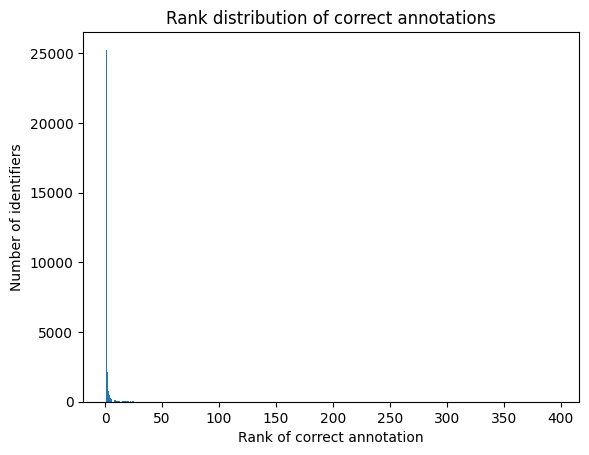

In [24]:
import matplotlib.pyplot as plt

plt.bar(hist["rank"], hist["count"])
plt.xlabel("Rank of correct annotation")
plt.ylabel("Number of identifiers")
plt.title("Rank distribution of correct annotations")
plt.show()